In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow


In [ ]:
img=cv2.imread('/content/Task2.jpg',cv2.IMREAD_GRAYSCALE)

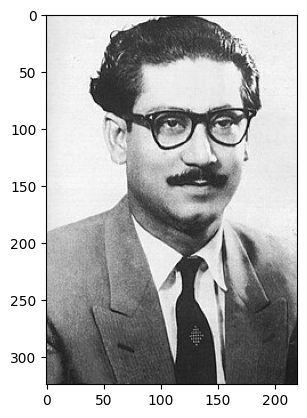

In [ ]:
plt.imshow(img,cmap='gray')

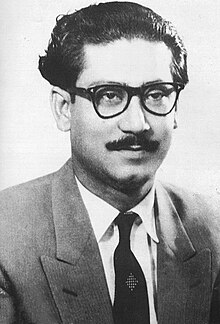

In [ ]:
img2=img.copy()
# img2=cv2.resize(img2)
cv2_imshow(img2)


In [ ]:
img.shape

(324, 220)

array([[225, 224, 223, ..., 242, 245, 243],
       [224, 225, 226, ..., 240, 243, 241],
       [222, 225, 227, ..., 242, 243, 241],
       ...,
       [ 99,  92,  88, ...,  31,  31,  29],
       [ 96,  95,  92, ...,  33,  33,  31],
       [108, 108, 105, ...,  35,  35,  33]], dtype=uint8)
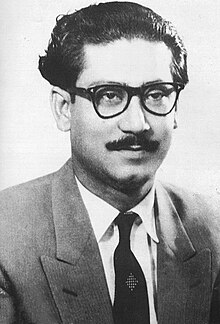

In [ ]:
img

In [ ]:
img=cv2.resize(img2,(512,512))

In [ ]:
unique_values, counts = np.unique(img, return_counts=True)

In [ ]:
total_pixels = img.size
pdf = counts / total_pixels

In [ ]:
cdf = np.cumsum(pdf) * 255

In [ ]:
equalized_cdf = np.where(cdf - np.floor(cdf) > 0.5, np.ceil(cdf), np.floor(cdf)).astype(int)

In [ ]:
import pandas as pd

pixel_table = pd.DataFrame({
    'values': unique_values,
    'occurrence': counts,
    'PDF': pdf,
    'CDF': cdf,
    'Equalized' : equalized_cdf
})

In [ ]:
display(pixel_table)

,values,occurrence,PDF,CDF,Equalized
0,2,2,0.000008,0.001945,0
1,4,2,0.000008,0.003891,0
2,5,3,0.000011,0.006809,0
3,6,4,0.000015,0.010700,0
4,7,5,0.000019,0.015564,0
...,...,...,...,...,...
248,251,153,0.000584,254.736385,255
249,252,101,0.000385,254.834633,255
250,253,80,0.000305,254.912453,255
251,254,62,0.000237,254.972763,255


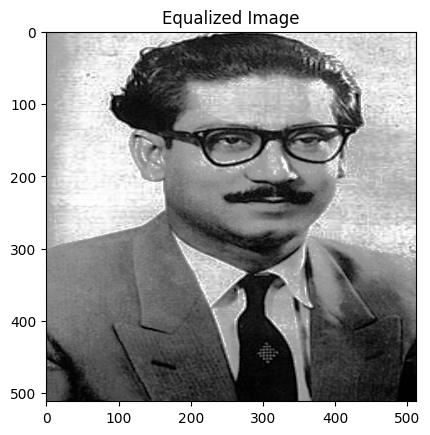

In [ ]:
equalized_image_array = np.zeros_like(img)

for i in range(img.shape[0]):
  for j in range(img.shape[1]):
    original_pixel_value = img[i, j]
    equalized_value = equalized_cdf[np.where(unique_values == original_pixel_value)[0][0]]
    equalized_image_array[i, j] = equalized_value

plt.imshow(equalized_image_array, cmap='gray')
plt.title('Equalized Image')
plt.show()

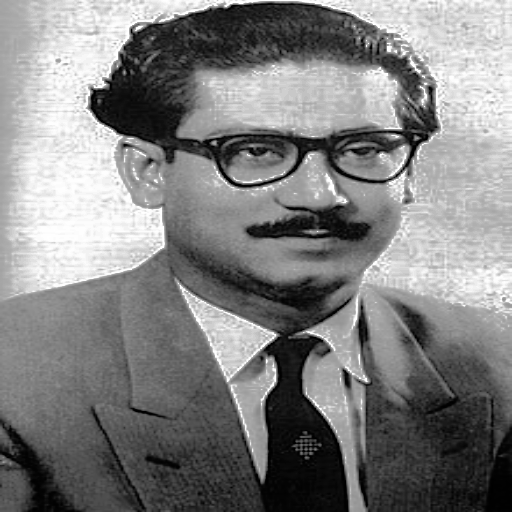

In [ ]:
cv2_imshow(equalized_image_array)

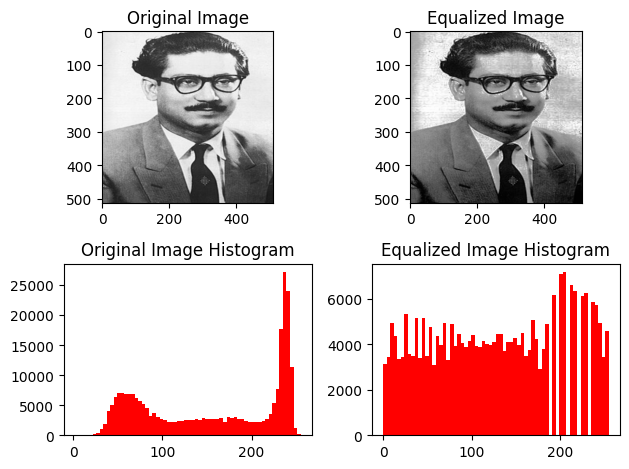

In [ ]:
# plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.subplot(2,2,2)
plt.imshow(equalized_image_array,cmap='gray')
plt.title('Equalized Image')
plt.subplot(2,2,3)
plt.hist(img.flatten(),bins=64,color='red')
plt.title('Original Image Histogram')
plt.subplot(2,2,4)
plt.hist(equalized_image_array.flatten(),bins=64,color='red')
plt.title('Equalized Image Histogram')
plt.tight_layout()
plt.show()